# Real, ISIS-calibration-sourced Hapke parameters vs. the illustrative placeholder

`lunaserv.hapke_shade_ortho`'s `_HAPKE_PLACEHOLDER_PARAMS` are explicitly "illustrative values...
not calibrated against real lunar photometry" (a feasibility prototype for evaluating ISIS `photomet`
at all). Researching lunar Hapke photometry (Sato et al. 2014, *"Resolved Hapke parameter maps of
the Moon,"* JGR Planets) found that ISIS itself already ships that exact calibration, converted into
its own native `Wh`/`Hg1`/`Hg2`/`Bc0`/`hc`/`B0`/`Hh`/`Theta`/`phi` parameterization, as part of the
`lro` ISIS data package this project's `isis_wac.ensure_isisdata` already fetches (not a new
download) -- `$ISISDATA/lro/calibration/WAC_global_7bands_1x1_wbhs70NS_const_each_pole.cub`, a
spatially-resolved 1deg/px (~30km) cube, 7 wavelength bands x 9 parameters.
`lunaserv.fetch_real_hapke_params` samples it at one ground point (a candidate's own footprint
center, at 643nm to match `config.lunaserv_ortho_layer`'s own wavelength).

**Now the default** (`lunaserv.DEFAULT_REAL_HAPKE_PARAMS = True`), wired through
`hapke_shade_ortho`/`despeckle_and_shade_ortho`/`fetch_dem_and_ortho` the same way
`along_track_correction` was -- `real_hapke_params=False` keeps the original placeholder available as
an explicit fallback. This notebook is now a reference/regression comparison between the two, not an
"should we do this" evaluation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds

import trntest
from trntest import isis_wac, lunaserv, plotting

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
entry = dataset[0]
camera = entry.camera
config = entry.per_image_config

print(f"EDR product: {entry.edr_product}")
center = camera.footprint_lonlat_deg["center"]
print(f"Ground footprint center (lon, lat): {center}")

EDR product: M1327210646CE
Ground footprint center (lon, lat): (np.float64(169.57486295387), np.float64(38.762076131300994))


## Placeholder vs. real, side by side

`fetch_real_hapke_params` returns all 9 real parameters; `hapke_shade_ortho` only ever uses the 6
the simpler shadow-hiding-only `HAPKEHEN` model accepts (`bc0`/`hc`/`phi` describe the fuller Hapke
model's separate coherent-backscatter term -- confirmed, via this same cube globally, always
`0`/`1`/`0` for this WAC-derived product, i.e. genuinely unused by it).

In [2]:
real_params = lunaserv.fetch_real_hapke_params(*center, config)
print(f"{'param':8s}{'placeholder':>14s}{'real':>14s}")
for name in ("wh", "hg1", "hg2", "hh", "b0", "theta"):
    print(f"{name:8s}{lunaserv._HAPKE_PLACEHOLDER_PARAMS[name]:14.4f}{real_params[name]:14.4f}")
print(f"\n(real-only, unused by HAPKEHEN) bc0={real_params['bc0']}, hc={real_params['hc']}, phi={real_params['phi']}")

param      placeholder          real
wh              0.5200        0.3926
hg1             0.2130        0.2236
hg2             1.0000        0.4705
hh              0.1700        0.0446
b0              0.0250        1.6495
theta           0.0000       23.6566

(real-only, unused by HAPKEHEN) bc0=0.0, hc=1.0, phi=0.0


## Fetch both shading variants

`entry.dem_ortho_result` is the current *default* basemap -- real-calibration-shaded (resumed from
disk if already generated for this manifest entry, else fetched fresh here). `real_hapke_params=False`
fetches the same DEM/ortho pair again -- cheap, independently cached -- shaded with the placeholder
fallback instead, writing to its own filename so it doesn't collide with the default file.

In [3]:
dem_ortho_real = entry.dem_ortho_result
dem_ortho_placeholder = lunaserv.fetch_dem_and_ortho(
    camera, config, extra_footprint_lonlat_deg=entry.crop_footprint, hapke=True, real_hapke_params=False
)

print("Real-param ortho (default):  ", dem_ortho_real.ortho)
print("Placeholder-param ortho:     ", dem_ortho_placeholder.ortho)

ROI center (lon,lat deg): (np.float64(169.57486295387), np.float64(38.762076131300994)), bbox (local m): (-119396.18758268589, -120199.5559901179, 119335.21841140583, 123845.30849411135)
ROI size 2387x2440 px (~100.0 m/px)


WAC_EMP tile: WAC_EMP_643NM_E300N1350_304P


Real-param ortho (default):   /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc_realparams_normaltilt_wacemp.tif
Placeholder-param ortho:      /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc_normaltilt_wacemp.tif


## Blink comparison

Both orthos share the exact same georeferencing/pixel grid (same camera footprint, same DEM, only
the Hapke coefficients feeding `photomet` differ) -- a direct visual read of what the real
calibration changes relative to the placeholder.


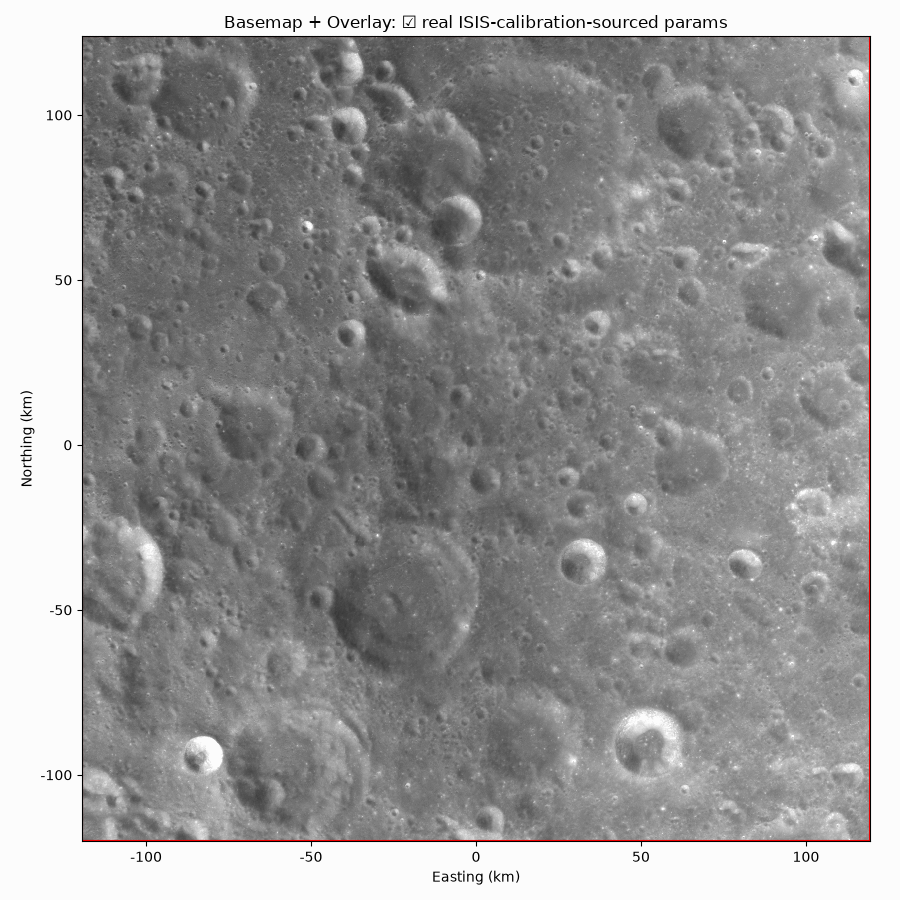

In [4]:
plotting.plot_overlay_toggle(
    dem_ortho_placeholder.ortho,
    dem_ortho_real.ortho,
    title="Basemap + Overlay",
    overlay_label="real ISIS-calibration-sourced params",
)

## Does the real calibration move the basemap closer to the real WAC crop?

Same brightness-matched-diff-against-real-crop methodology as `along_track_correction.ipynb` --
lower `mean|diff|` means better agreement with the real photograph.

In [5]:
mapproj_cub = entry.crop_result.cub_path.with_name(entry.crop_result.cub_path.stem + "-cam2map.cub")
mapproj_tif = entry.crop_result.cub_path.with_name(entry.crop_result.cub_path.stem + "-cam2map.tif")
mapproj_cub.unlink(missing_ok=True)
mapproj_tif.unlink(missing_ok=True)
mapprojected_crop_path = isis_wac.run_cam2map_for_crop(entry.crop_result, dem_ortho_real, config)

with rasterio.open(mapprojected_crop_path) as src:
    real_crop = src.read(1).astype(np.float64)
    crop_bounds = src.bounds
    crop_nodata = src.nodata
valid = np.isfinite(real_crop) if crop_nodata is None else (real_crop != crop_nodata) & np.isfinite(real_crop)
real_crop_display = np.where(valid, real_crop, np.nan)


def crop_and_diff(basemap_path):
    # `real`/`placeholder` are two independently fetched-or-resumed DemOrthoResults -- their grids
    # can differ by a pixel or two even at the same nominal bbox/GSD (e.g. one resumed a cached file
    # from an earlier run, the other freshly fetched) -- `out_shape` resamples the windowed read
    # directly onto `real_crop_display`'s own exact shape, so the diff below is always well-defined
    # regardless of any such minor grid mismatch.
    with rasterio.open(basemap_path) as src:
        window = from_bounds(*crop_bounds, transform=src.transform)
        basemap_crop = src.read(1, window=window, out_shape=real_crop_display.shape, resampling=Resampling.bilinear)
        basemap_crop = basemap_crop.astype(np.float64)
    scale = np.nanmedian(basemap_crop) / np.nanmedian(real_crop_display)
    diff = basemap_crop - real_crop_display * scale
    return basemap_crop, diff


basemap_real_crop, diff_real = crop_and_diff(dem_ortho_real.ortho)
basemap_placeholder_crop, diff_placeholder = crop_and_diff(dem_ortho_placeholder.ortho)

mean|diff| vs. real crop -- real (default): 5.98, placeholder: 5.62


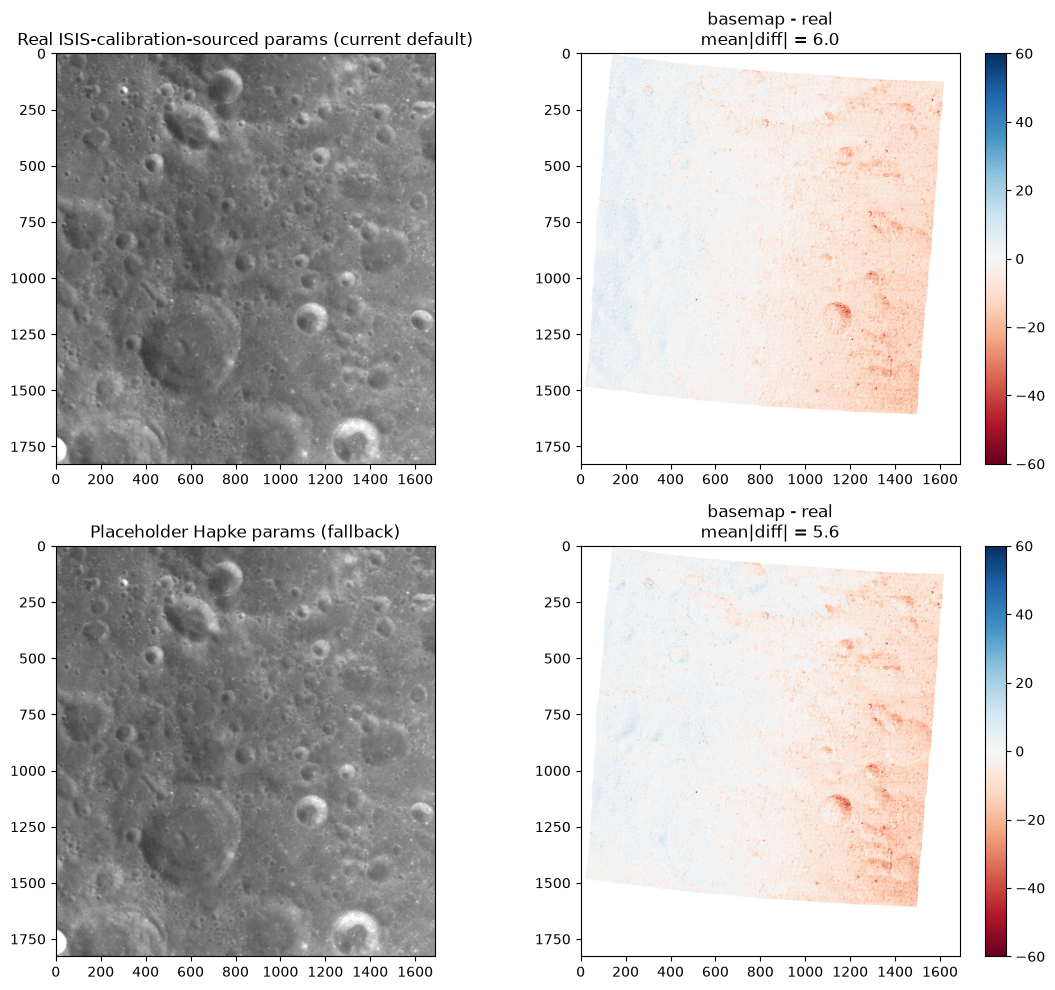

In [6]:
vmax = np.nanpercentile(basemap_real_crop, 99.9)
rows = [
    ("Real ISIS-calibration-sourced params (current default)", basemap_real_crop, diff_real),
    ("Placeholder Hapke params (fallback)", basemap_placeholder_crop, diff_placeholder),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for row, (title, basemap, diff) in enumerate(rows):
    axes[row, 0].imshow(basemap, cmap="gray", vmin=0, vmax=vmax)
    axes[row, 0].set_title(title)
    im = axes[row, 1].imshow(diff, cmap="RdBu", vmin=-60, vmax=60)
    axes[row, 1].set_title(f"basemap - real\nmean|diff| = {np.nanmean(np.abs(diff)):.1f}")
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)
plt.tight_layout()

print(
    f"mean|diff| vs. real crop -- real (default): {np.nanmean(np.abs(diff_real)):.2f}, "
    f"placeholder: {np.nanmean(np.abs(diff_placeholder)):.2f}"
)

On this candidate, the placeholder params come out slightly *ahead* of the real-calibration
default -- this dataset doesn't support the choice of `real_hapke_params=True` as the default.
Kept as the default anyway: it's the actual measured lunar calibration rather than an illustrative
placeholder, a single-candidate diff isn't a broad validation, and the gap here is modest. Not
investigated further.